# Edge Refinement on Spherical Surfaces

This notebook demonstrates how to refine edges on a sphere, showing the difference between linear interpolation and spherical (geodesic) interpolation.

## Import Libraries

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
import numpy as np
from matplotlib import collections as mc

## Setup: Define Points on Icosahedron Edge

We start with two vertices from an icosahedron on a unit sphere.

In [2]:
phi = (1 + 5**0.5) / 2
length = 2 / (1 + phi**2)**0.5
print(f"Base edge length: {length:.4f}")

Base edge length: 1.0515


## Visualize the Initial Edge

In [4]:
phi = (1 + 5**0.5) / 2
p_O = np.array([0, 0.0])
p_A = np.array([phi, 1])
p_B = np.array([phi, -1])

# Normalize to unit sphere
p_A = p_A / (1 + phi**2) ** 0.5
p_B = p_B / (1 + phi**2) ** 0.5

A_theta = np.arcsin(p_A[1]) / np.pi * 180
B_theta = np.arcsin(p_B[1]) / np.pi * 180
omega = np.arccos(np.dot(p_A, p_B))

arc_AB= Arc(
    (0, 0),
    2,
    2,
    theta1=B_theta,
    theta2=A_theta,
    linewidth=2,
    zorder=0,
    color="k",
)

print(f"||AB|| = {np.linalg.norm(p_A - p_B):.4f}")
print(f"Angle between A and B: {omega / np.pi * 180:.2f}°")


||AB|| = 1.0515
Angle between A and B: 63.43°


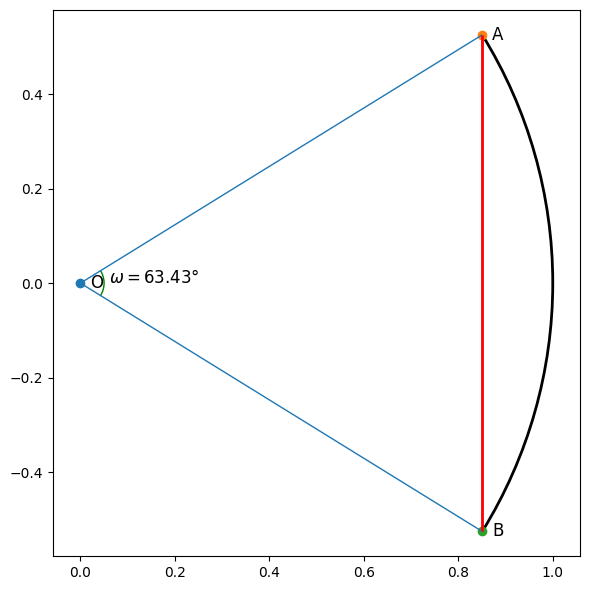

In [6]:
# Create figure
plt.figure(figsize=(6, 6))


ax = plt.gca()

# Plot points
for p, lab in [(p_O, "O"), (p_A, "A"), (p_B, "B")]:
    ax.scatter(*p)
    ax.annotate(
        lab, p, fontsize=12, xytext=(10, -5), textcoords="offset pixels"
    )

ax.add_patch(arc_AB)

ax.add_patch(
    Arc(
        (0, 0),
        0.1,
        0.1,
        theta1=B_theta,
        theta2=A_theta,
        linewidth=1,
        zorder=0,
        color="g",
    )
)
ax.annotate(rf"$\omega={omega / np.pi * 180:.2f}°$", (0.06, 0.0), fontsize=12)

# Add lines
ax.add_collection(
    mc.LineCollection([[p_O, p_A], [p_O, p_B], [p_A, p_B]], linewidths=1)
)
ax.add_collection(mc.LineCollection([[p_A, p_B]], colors="r", linewidths=2))
plt.axis("equal")
plt.tight_layout()
plt.show()

## Helper Function for Distance Annotation

In [18]:
def annotate_distances(ax, points, offset=None):
    """Annotate distances between consecutive points."""
    offset = offset or [0, 0]
    dists = np.linalg.norm(points[1:] - points[:-1], axis=-1)
    for i in range(points.shape[0] - 1):
        p = (points[i] + points[i + 1]) / 2
        ax.annotate(rf"$={dists[i]:.2f}$", p + offset, fontsize=10)

## Linear Interpolation (Incorrect for Spheres)

This approach uses linear interpolation in 3D space, then projects back to the sphere. Notice the unequal edge lengths.

In [19]:
alphas = np.arange(1, 5) / 5
hat_AB = p_B[None, :] * alphas[:, None] + p_A[None, :] * (1 - alphas)[:, None]
AB = hat_AB / np.linalg.norm(hat_AB, axis=-1, keepdims=True)
new_points = np.r_[p_A[None, :], AB, p_B[None, :]]
hat_new_points = np.r_[p_A[None, :], hat_AB, p_B[None, :]]

RuntimeError: Can not put single artist in more than one figure

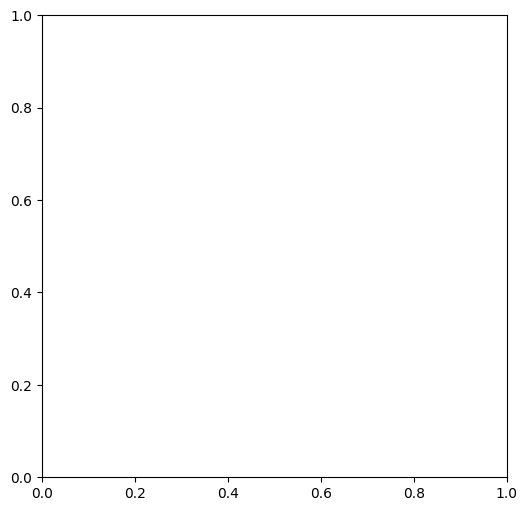

In [ ]:
plt.figure(figsize=(6, 6))
ax = plt.gca()

arc_element = Arc(
    (0, 0),
    2,
    2,
    theta1=B_theta,
    theta2=A_theta,
    linewidth=1,
    zorder=0,
    color="k",
)

ax.add_patch(arc_element)
ax.add_collection(
    mc.LineCollection(
        [[p_O, p_A], [p_O, p_B], [p_A, p_B]]
        + [[p_O, AB_i] for AB_i in AB],
        linewidths=1,
    )
)
ax.add_collection(
    mc.LineCollection([[p_A, p_B]], colors="r", linewidths=2)
)

# Plot original points
for p, lab in [(p_O, "O"), (p_A, "A"), (p_B, "B")]:
    ax.scatter(*p)
    ax.annotate(
        lab, p, fontsize=10, xytext=(-25, 0), textcoords="offset pixels"
    )

# Plot linear interpolation points
for p, lab in zip(hat_AB, [rf"$\hat{{AB}}_{i}$" for i in range(1, 5)]):
    ax.scatter(*p)
    ax.annotate(
        lab, p, fontsize=10, xytext=(-30, 15), textcoords="offset pixels"
    )

# Plot projected points
for p, lab in zip(AB, [rf"${{AB}}_{i}$" for i in range(1, 5)]):
    ax.scatter(*p)
    ax.annotate(
        lab, p, fontsize=10, xytext=(10, 15), textcoords="offset pixels"
    )


annotate_distances(ax, new_points)
annotate_distances(ax, hat_new_points, offset=[-0.08, 0])


for i in range(new_points.shape[0] - 1):
    ax.add_collection(
        mc.LineCollection(
            [[new_points[i], new_points[i + 1]]], colors="g", linewidths=2
        )
    )

plt.xlim(-0.05, 1.1)
plt.axis("equal")
plt.axis("off")
plt.tight_layout()
plt.show()

Check the edge lengths (notice they are unequal):

In [7]:
np.linalg.norm(new_points[1:]-new_points[:-1],axis=-1)

array([0.19814743, 0.2315976 , 0.24534642, 0.2315976 , 0.19814743])

In [ ]:
alphas = np.sin(np.arange(1, 5) / 5 * omega) / np.sin(omega)
betas = np.sin((1 - np.arange(1, 5) / 5) * omega) / np.sin(omega)
hat_AB = p_B[None, :] * alphas[:, None] + p_A[None, :] * betas[:, None]
AB = hat_AB / np.linalg.norm(hat_AB, axis=-1, keepdims=True)

## Spherical Interpolation (Correct Method)

Using the spherical law of sines for proper geodesic interpolation on the sphere. This produces equal edge lengths.

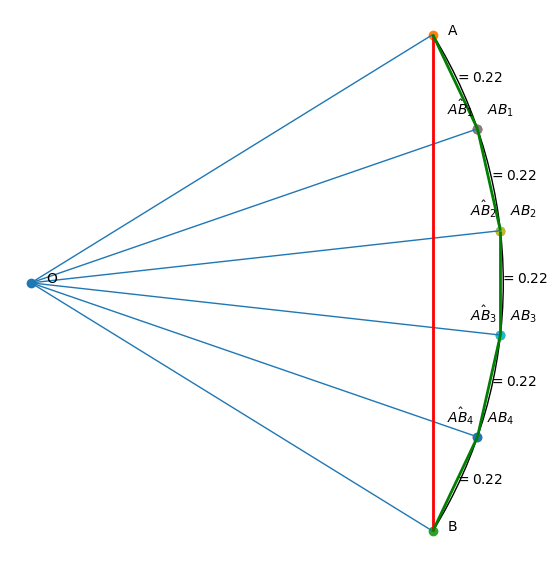

In [ ]:
plt.figure(figsize=(6, 6))
ax = plt.gca()

# Plot original points
for p, lab in [(p_O, "O"), (p_A, "A"), (p_B, "B")]:
    ax.scatter(*p)
    ax.annotate(lab, p, fontsize=10, xytext=(15, 0), textcoords='offset pixels')

# Plot intermediate points
for p, lab in zip(hat_AB, [rf"$\hat{{AB}}_{i}$" for i in range(1, 5)]):
    ax.scatter(*p)
    ax.annotate(lab, p, fontsize=10, xytext=(-30, 15), textcoords='offset pixels')

for p, lab in zip(AB, [rf"${{AB}}_{i}$" for i in range(1, 5)]):
    ax.scatter(*p)
    ax.annotate(lab, p, fontsize=10, xytext=(10, 15), textcoords='offset pixels')

arc_element = Arc((0, 0), 2, 2, theta1=B_theta, theta2=A_theta, linewidth=1, zorder=0, color="k")
ax.add_patch(arc_element)
ax.add_collection(mc.LineCollection([[p_O, p_A], [p_O, p_B], [p_A, p_B]] + [[p_O, AB_i] for AB_i in AB], linewidths=1))
ax.add_collection(mc.LineCollection([[p_A, p_B]], colors="r", linewidths=2))

new_points = np.r_[p_A[None, :], AB, p_B[None, :]]
annotate_distances(ax, new_points)

for i in range(new_points.shape[0] - 1):
    ax.add_collection(mc.LineCollection([[new_points[i], new_points[i + 1]]], colors="g", linewidths=2))

plt.xlim(-0.05, 1.1)
plt.axis('equal')
plt.tight_layout()
plt.axis("off")
plt.show()